In [25]:
import pandas as pd
import numpy as np
import os
import pickle
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import het_arch

In [2]:
base_dir = Path(os.getenv("LASSO_OUTPUT_DIR", "output"))
features_path = Path("output") / "features.pkl"
response_path = Path("output") / "response.pkl"

with features_path.open("rb") as f:
    X = pickle.load(f)

In [4]:
def to_ar1_innovations(X: pd.DataFrame, min_obs: int = 30) -> pd.DataFrame:
    """Return AR(1) innovations (residuals) for each column of X."""
    X_innov = pd.DataFrame(index=X.index, columns=X.columns, dtype="float64")

    for col in X.columns:
        s = pd.to_numeric(X[col], errors="coerce")
        tmp = pd.DataFrame({"x": s, "x_lag1": s.shift(1)}).dropna()
        if len(tmp) < min_obs or tmp["x"].nunique() < 3 or tmp["x_lag1"].nunique() < 3:
            continue

        res = sm.OLS(tmp["x"], sm.add_constant(tmp["x_lag1"])).fit()
        X_innov.loc[tmp.index, col] = res.resid

    return X_innov

In [11]:
X

,Natural disasters,Internet,Soft drinks,Mobile devices,Profits,M&A,Changes,Police/crime,Research,Executive pay,...,European politics,Size,NASD,Mexico,Retail,Long/short term,Wide range,Lawsuits,UK,Revenue growth
0,0.001988,0.000122,0.002666,0.001261,0.004741,0.001871,0.001570,0.004197,0.003983,0.005566,...,0.010827,0.000634,0.004283,0.004061,0.011505,0.005036,0.004582,0.007834,0.003409,0.001587
1,-0.000171,0.000351,0.003686,-0.000371,0.001765,0.002706,0.001763,0.004196,0.003722,0.000773,...,0.009825,0.003915,0.002771,0.003717,0.009248,0.004038,0.003852,0.002843,0.004201,0.003209
2,-0.001502,-0.000573,0.001597,-0.000617,0.004996,0.006042,-0.000919,-0.003869,-0.000489,0.019151,...,-0.006519,0.004867,0.000032,-0.001438,-0.002036,0.001628,-0.000151,0.010792,-0.001486,-0.001469
3,0.005026,0.000419,0.003161,0.000628,0.002374,-0.000484,0.006283,0.003560,0.008377,-0.003077,...,0.032461,0.002531,0.001466,0.003560,0.000838,0.003825,0.005026,0.004375,0.001047,0.002304
4,-0.000848,0.000664,0.001971,0.001244,0.002450,0.005010,0.000251,0.001143,0.006193,0.002946,...,-0.009459,0.002246,0.003356,0.002326,0.003591,0.003229,0.007213,0.011635,0.004541,0.001694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8434,0.020924,0.003490,0.001643,0.003830,0.000534,0.003352,0.003561,0.011832,0.004147,0.003475,...,0.004854,0.007005,0.002347,0.002092,0.002999,0.004009,0.005156,0.002215,0.002723,0.003256
8435,-0.009297,0.004544,0.001473,0.003733,0.000380,0.001679,0.003092,0.008746,0.003623,0.001306,...,0.009447,0.003206,0.002656,0.007440,0.004374,0.004111,0.004079,0.001532,0.005325,0.004548
8436,0.001057,0.008726,0.002418,0.005299,0.000649,0.001260,0.003215,0.001968,0.003508,0.002607,...,0.003807,0.003194,0.003099,0.002040,0.000957,0.005295,0.004748,0.006659,0.000562,0.003800
8437,-0.000199,0.009300,0.001921,0.009189,0.002168,0.004069,0.005021,0.010532,0.004754,0.001293,...,0.006678,0.004179,0.003493,0.001756,0.019825,0.005007,0.003039,0.003809,0.002058,0.007979


In [12]:
X_innov

,Natural disasters,Internet,Soft drinks,Mobile devices,Profits,M&A,Changes,Police/crime,Research,Executive pay,...,European politics,Size,NASD,Mexico,Retail,Long/short term,Wide range,Lawsuits,UK,Revenue growth
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.002318,-0.002764,-0.000027,-0.002661,-0.001029,-0.000464,-0.001621,0.001203,-0.000763,-0.002602,...,0.005378,-0.000092,-0.002537,0.000694,0.004100,-0.000415,-0.000586,-0.003095,0.001135,-0.000181
2,-0.004031,-0.003633,-0.002110,-0.003222,0.001840,0.002937,-0.004286,-0.006863,-0.004977,0.015572,...,-0.011055,0.000994,-0.005276,-0.004475,-0.007231,-0.002831,-0.004590,0.004680,-0.004513,-0.004715
3,0.002261,-0.002864,-0.000557,-0.002025,-0.000389,-0.003331,0.002679,-0.000661,0.003844,-0.005874,...,0.026477,-0.001303,-0.003842,0.000306,-0.004594,-0.000649,0.000582,-0.001460,-0.002254,-0.001357
4,-0.002457,-0.002380,-0.001738,-0.001169,-0.000632,0.001657,-0.002718,-0.001948,0.001755,-0.000796,...,-0.011989,-0.001684,-0.001952,-0.000718,-0.001780,-0.001232,0.002775,0.005576,0.001362,-0.001632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8434,0.018323,0.000869,-0.002073,0.002305,-0.002701,0.000292,0.000408,0.008411,-0.000342,0.000099,...,-0.000733,0.003125,-0.002961,-0.001007,-0.002392,-0.000440,0.000718,-0.003945,-0.000284,-0.000203
8435,-0.008092,0.002241,-0.002245,0.001940,-0.002926,-0.001376,-0.000117,0.006915,-0.000861,-0.002158,...,0.004471,-0.000541,-0.002652,0.004335,-0.000952,-0.000349,-0.000359,-0.004602,0.002226,0.001306
8436,-0.003088,0.006676,-0.001300,0.003488,-0.002676,-0.001925,-0.000036,-0.000333,-0.000981,-0.000949,...,-0.000762,-0.000708,-0.002209,-0.000839,-0.004340,0.000836,0.000309,0.000501,-0.002411,0.000673
8437,-0.002510,0.008258,-0.001793,0.007680,-0.001125,0.000852,0.001781,0.007200,0.000264,-0.002208,...,0.001609,0.000276,-0.001815,-0.001351,0.014456,0.000555,-0.001400,-0.002170,-0.001144,0.004786


In [7]:
X_innov = to_ar1_innovations(X)

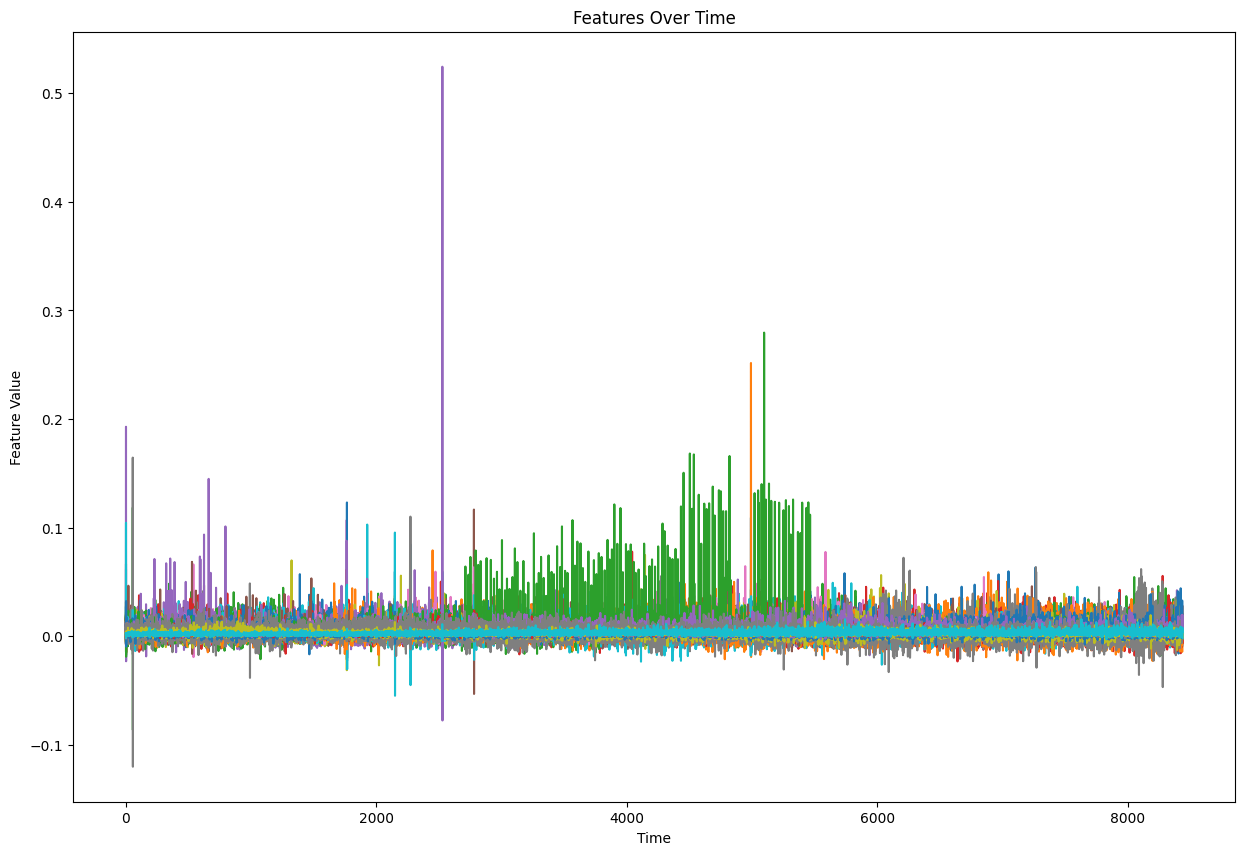

In [8]:
#plot all of the features over time
plt.figure(figsize=(15, 10))
for i in range(X.shape[1]):
    plt.plot(X.iloc[:, i])
plt.xlabel('Time')
plt.ylabel('Feature Value')
plt.title('Features Over Time')
plt.show()

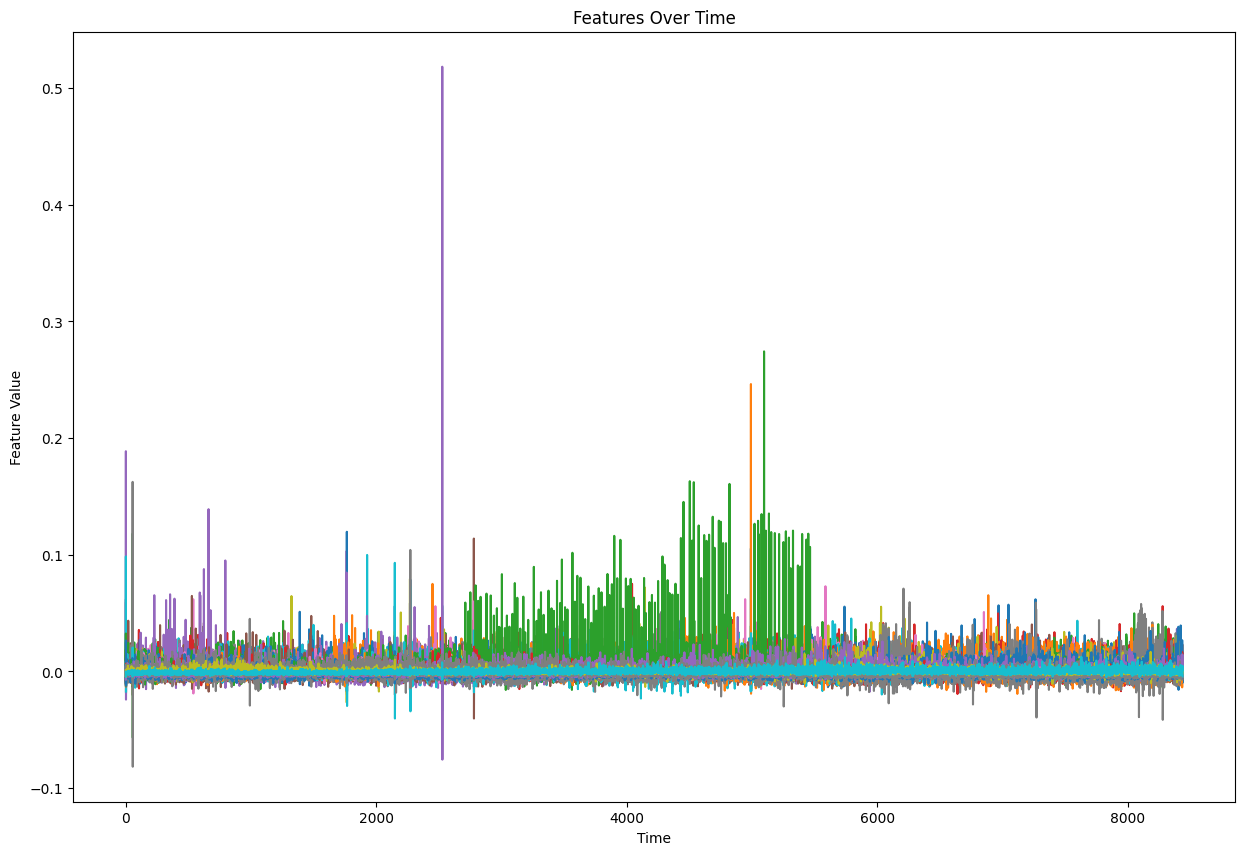

In [9]:
#plot all of the features over time
plt.figure(figsize=(15, 10))
for i in range(X_innov.shape[1]):
    plt.plot(X_innov.iloc[:, i])
plt.xlabel('Time')
plt.ylabel('Feature Value')
plt.title('Features Over Time')
plt.show()

Average pairwise correlation (off-diagonal): -0.0039
Average persistence (lag-1 autocorrelation): -0.0766


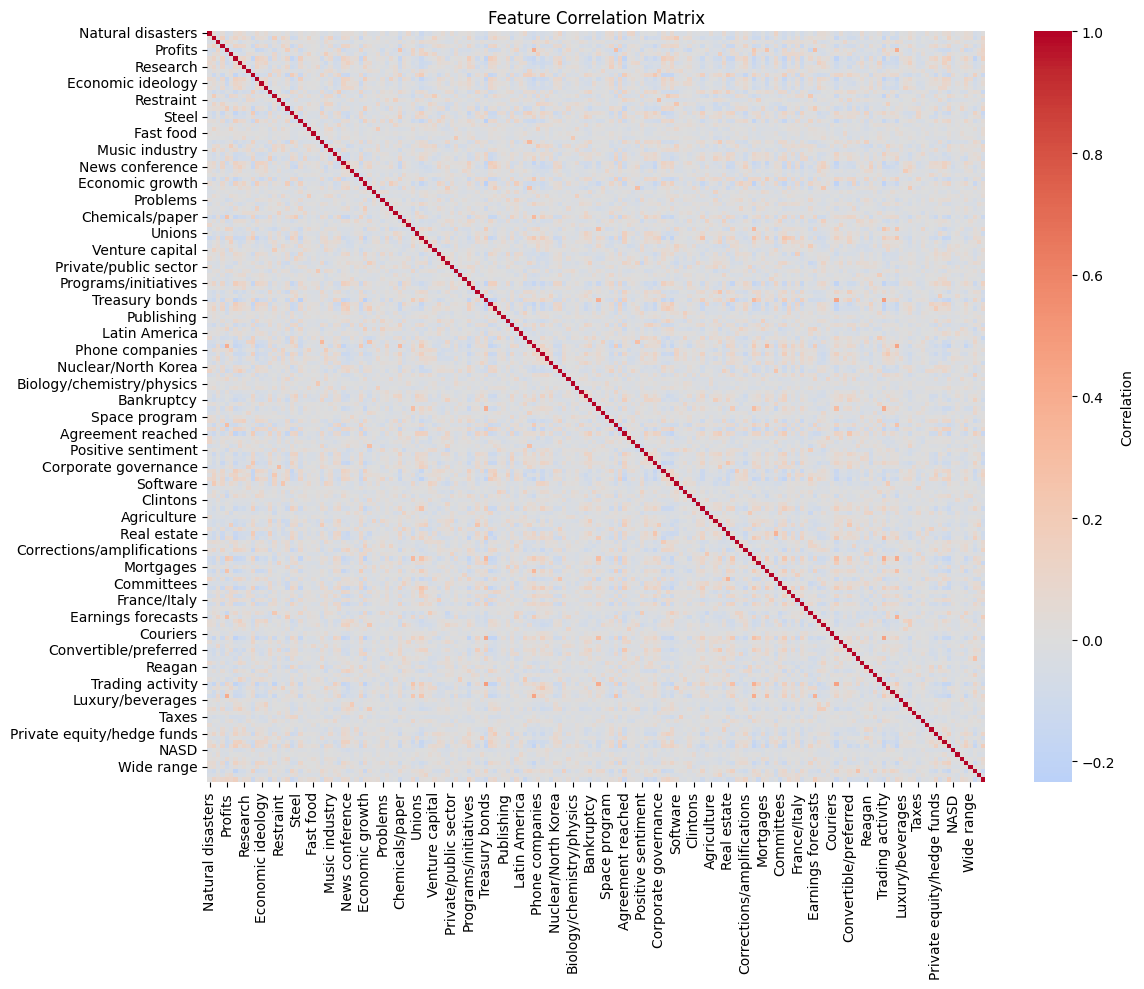

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
correlation_matrix = pd.DataFrame(X).corr()

# ---- Average off-diagonal correlation ----
corr_values = correlation_matrix.values
avg_corr = corr_values[np.triu_indices_from(corr_values, k=1)].mean()

print(f"Average pairwise correlation (off-diagonal): {avg_corr:.4f}")

# ---- Average persistence (lag-1 autocorrelation) ----
df = pd.DataFrame(X)
persistence_values = []

for col in df.columns:
    # Calculate lag-1 autocorrelation for each feature
    lag1_corr = df[col].autocorr(lag=1)
    if not np.isnan(lag1_corr):
        persistence_values.append(lag1_corr)

avg_persistence = np.mean(persistence_values)
print(f"Average persistence (lag-1 autocorrelation): {avg_persistence:.4f}")

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    ax=ax,
    cbar_kws={"label": "Correlation"}
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


Average pairwise correlation (off-diagonal): -0.0040
Average persistence (lag-1 autocorrelation): 0.0065


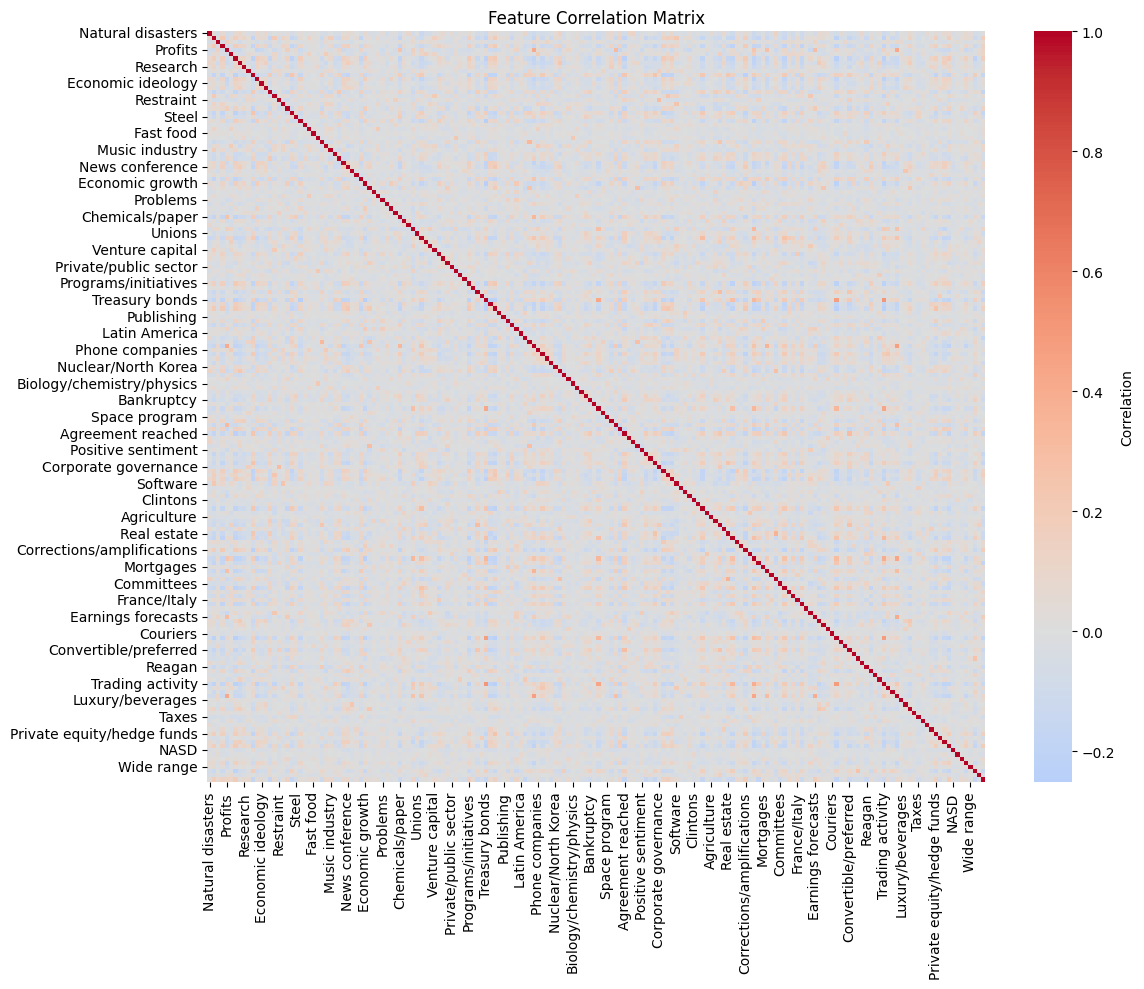

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
correlation_matrix = pd.DataFrame(X_innov).corr()

# ---- Average off-diagonal correlation ----
corr_values = correlation_matrix.values
avg_corr = corr_values[np.triu_indices_from(corr_values, k=1)].mean()

print(f"Average pairwise correlation (off-diagonal): {avg_corr:.4f}")

# ---- Average persistence (lag-1 autocorrelation) ----
df = pd.DataFrame(X_innov)
persistence_values = []

for col in df.columns:
    # Calculate lag-1 autocorrelation for each feature
    lag1_corr = df[col].autocorr(lag=1)
    if not np.isnan(lag1_corr):
        persistence_values.append(lag1_corr)

avg_persistence = np.mean(persistence_values)
print(f"Average persistence (lag-1 autocorrelation): {avg_persistence:.4f}")

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    ax=ax,
    cbar_kws={"label": "Correlation"}
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss, acf

def check_timeseries_requirements(X, feature_names=None, max_lag=20):
    """
    Check stationarity and autocorrelation for time series predictors.
    
    Parameters:
    -----------
    X : array-like or DataFrame
        Time series data (observations x features)
    feature_names : list, optional
        Names of features
    max_lag : int
        Maximum lag for autocorrelation analysis
    """
    df = pd.DataFrame(X)
    if feature_names is not None:
        df.columns = feature_names
    
    print("=" * 80)
    print("TIME SERIES REQUIREMENTS CHECK")
    print("=" * 80)
    
    results = []
    
    for i, col in enumerate(df.columns):
        series = df[col].dropna()
        
        print(f"\n{'='*80}")
        print(f"Feature {i}: {col if isinstance(col, str) else f'Column {col}'}")
        print(f"{'='*80}")
        
        result = {'feature': col}
        
        # STATIONARITY - ADF TEST
        print("\nADF Test (Stationarity):")
        print("-" * 40)
        adf_result = adfuller(series, autolag='AIC')
        result['adf_statistic'] = adf_result[0]
        result['adf_pvalue'] = adf_result[1]
        result['adf_stationary'] = adf_result[1] < 0.05
        
        print(f"  Statistic: {adf_result[0]:.4f}")
        print(f"  p-value: {adf_result[1]:.4f}")
        print(f"  → {'STATIONARY ✓' if adf_result[1] < 0.05 else 'NON-STATIONARY ✗ (consider differencing)'}")
    
        
        # AUTOCORRELATION
        print("\nAutocorrelation:")
        print("-" * 40)
        acf_values = acf(series, nlags=min(max_lag, len(series)//4), fft=False)
        result['lag1_autocorr'] = acf_values[1] if len(acf_values) > 1 else np.nan
        result['significant_lags'] = np.sum(np.abs(acf_values[1:]) > 1.96/np.sqrt(len(series)))
        
        print(f"  Lag-1 autocorrelation: {acf_values[1]:.4f}")
        print(f"  Significant lags (out of {max_lag}): {result['significant_lags']}")
        
        if result['significant_lags'] > max_lag * 0.3:
            print(f"  → HIGH AUTOCORRELATION ⚠ (may need lagged dependent variable)")
        else:
            print(f"  → Moderate autocorrelation ✓")
        
        results.append(result)
    
    # SUMMARY TABLE
    print("\n" + "=" * 80)
    print("SUMMARY TABLE")
    print("=" * 80)
    
    results_df = pd.DataFrame(results)
    summary_cols = ['feature', 'adf_stationary', 'lag1_autocorr', 'significant_lags']
    print(results_df[summary_cols].to_string(index=False))
    
    # RECOMMENDATIONS
    print("\n" + "=" * 80)
    print("RECOMMENDATIONS")
    print("=" * 80)
    
    n_nonstationary_adf = (~results_df['adf_stationary']).sum()
    
    if n_nonstationary_adf > 0:
        print(f"\n⚠ {n_nonstationary_adf} features appear NON-STATIONARY")
        print("  → Consider: first differencing, detrending, or log transformation")
    else:
        print("\n✓ All features appear STATIONARY")
    
    high_autocorr = (results_df['significant_lags'] > max_lag * 0.3).sum()
    if high_autocorr > 0:
        print(f"\n⚠ {high_autocorr} features have HIGH AUTOCORRELATION")
        print("  → Consider: adding lagged dependent variable or using dynamic models")
    
    print("\n" + "=" * 80)
    
    return results_df


# USAGE
results = check_timeseries_requirements(X, max_lag=20)

TIME SERIES REQUIREMENTS CHECK

Feature 0: Natural disasters

ADF Test (Stationarity):
----------------------------------------
  Statistic: -12.7370
  p-value: 0.0000
  → STATIONARY ✓

Autocorrelation:
----------------------------------------
  Lag-1 autocorrelation: -0.1770
  Significant lags (out of 20): 20
  → HIGH AUTOCORRELATION ⚠ (may need lagged dependent variable)

Feature 1: Internet

ADF Test (Stationarity):
----------------------------------------
  Statistic: -2.5310
  p-value: 0.1081
  → NON-STATIONARY ✗ (consider differencing)

Autocorrelation:
----------------------------------------
  Lag-1 autocorrelation: -0.2410
  Significant lags (out of 20): 20
  → HIGH AUTOCORRELATION ⚠ (may need lagged dependent variable)

Feature 2: Soft drinks

ADF Test (Stationarity):
----------------------------------------
  Statistic: -10.6361
  p-value: 0.0000
  → STATIONARY ✓

Autocorrelation:
----------------------------------------
  Lag-1 autocorrelation: -0.0051
  Significant lags (o